# Evaluation - Comparing CGAN and Conditional Diffusion 

## Plan

1. Understand how to measure the quality and diversity of generated data using **FID**.  
2. Compare **cGAN vs Diffusion** outputs visually and statistically.  
3. Train a downstream **handwriting classifier** using synthetic data.  
4. Assess which generative approach produces more *useful* data for CAPTCHA robustness.



### Objectives to check
+ Do the samples look human like 
+ we would measure the quantititative quality using Frechet Inception Distance 
+ Also work on using sythetic data from each model to train a useful classifier

In [1]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, TensorDataset
from torchvision.models import inception_v3
from torchvision.utils import make_grid
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import os, sys
from scipy import linalg


from utils.visualize import show_batch
from utils.checkpoint import load_checkpoint
from torchmetrics.image.fid import FrechetInceptionDistance

We’ll now load both trained models — the **cGAN** and **Diffusion** generators —  
and use them to generate a fixed number of samples for evaluation.

In [2]:
from model.cgan import Generator
from model.diffusion import ConditionalUNet
from training.train_diffusion import sample_images

device = (
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print(f" Using device: {device}")



 Using device: cuda


In [3]:
# Helper Functions

from torchvision import datasets, transforms
def get_real_examples_per_class(n_classes=10, diffusion=False):
    """
    Deterministically extracts one MNIST image per class (0–9)
    directly from the dataset without shuffle.
    """
    if diffusion:
        transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,))
            ])
    else:
        transform = transforms.Compose([
            transforms.Resize(64),
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,))
            ])
    mnist = datasets.MNIST(root="../data", train=False, download=True, transform=transform)

    imgs, labels = [], []
    for cls in range(n_classes):
        for i in range(len(mnist)):
            if mnist[i][1] == cls:
                imgs.append(mnist[i][0])
                labels.append(cls)
                break  # stop at first match
    return torch.stack(imgs), torch.tensor(labels)




def get_representative_images(imgs, labels, n_classes=10):
    """
    Returns one representative image per class label (0–9).
    Ensures true label alignment for real datasets.
    """
    reps = []
    for i in range(n_classes):
        idx = (labels == i).nonzero(as_tuple=True)[0]
        if len(idx) > 0:
            reps.append(imgs[idx[0]])
        else:
            reps.append(torch.zeros_like(imgs[0]))  
    return torch.stack(reps)


@torch.no_grad()
def generate_conditioned_samples_cgan(generator, z_dim=100, device="cuda", n_classes=10):
    """
    Generate one representative sample per class (0–9) from cGAN.
    """
    generator.eval()
    zs = torch.randn(n_classes, z_dim, 1, 1, device=device)
    ys = torch.arange(n_classes, dtype=torch.long, device=device)
    imgs = generator(zs, ys).cpu()
    return imgs, ys.cpu()


@torch.no_grad()
def generate_conditioned_samples_diffusion(
    model,
    device="cuda",
    n_classes=10,
    timesteps=1000,          # used same as training
    img_size=(1, 28, 28)
):
    """
    Generate one representative diffusion sample per class (0–9), 
    using the same sampling logic as training-time generation.
    """
    from training.train_diffusion import linear_beta_schedule
    model.eval()

    betas = linear_beta_schedule(timesteps).to(device)
    alphas = 1.0 - betas
    alphas_cumprod = torch.cumprod(alphas, 0)

    imgs_list, labels_list = [], []

    for cls in range(n_classes):
        # Conditioning label for this class
        labels = torch.full((1,), cls, dtype=torch.long, device=device)
        imgs = torch.randn(1, *img_size).to(device)

        # Reverse diffusion loop (same as training sampler)
        for t in reversed(range(timesteps)):
            t_tensor = torch.full((1,), t, device=device, dtype=torch.long)
            pred_noise = model(imgs, t_tensor, labels)
            alpha = alphas[t]
            alpha_bar = alphas_cumprod[t]

            # Predict next sample
            noise = torch.randn_like(imgs) if t > 0 else torch.zeros_like(imgs)
            imgs = (1 / torch.sqrt(alpha)) * (
                imgs - ((1 - alpha) / torch.sqrt(1 - alpha_bar)) * pred_noise
            ) + torch.sqrt(betas[t]) * noise

        imgs_list.append(imgs[0].cpu())
        labels_list.append(cls)

    imgs_tensor = torch.stack(imgs_list)
    labels_tensor = torch.tensor(labels_list)
    return imgs_tensor, labels_tensor


def plot_real_cgan_diffusion(real_imgs, cgan_imgs, diff_imgs, n_classes=10):
    """
    Visual comparison between Real, cGAN, and Diffusion images.
   
    """

    fig, axs = plt.subplots(3, n_classes, figsize=(12, 4))
    fig.suptitle(" Comparison: Real vs cGAN vs Diffusion", fontsize=14, fontweight="bold")

    row_titles = [
        "Ground Truth",
        "CGAN",
        "Diffusion"
    ]
    row_colors = ["green", "royalblue", "darkorange"]

    # Plot each row
    for row_idx, row_imgs in enumerate([real_imgs, cgan_imgs, diff_imgs]):
        for i in range(n_classes):
            axs[row_idx, i].imshow(row_imgs[i].squeeze(), cmap="gray")
            axs[row_idx, i].axis("off")
            axs[row_idx, i].set_title(f"Class {i}", fontsize=8, pad=2)

    # Manually place row labels on figure (not as axis labels)
    for idx, (title, color) in enumerate(zip(row_titles, row_colors)):
        fig.text(
            0.02,                                   # x-position (left margin)
            0.84 - idx * 0.32,                      # y-position per row
            title,
            fontsize=11,
            color=color,
            fontweight="bold",
            va="center"
        )

    plt.subplots_adjust(left=0.12, right=0.98, top=0.9, bottom=0.05, hspace=0.3)
    plt.show()

In [4]:


def compute_fid(real_imgs, fake_imgs, device="cuda", batch_size=128):
    """
    Compute FID safely in GPU batches to prevent OOM.
    Works with TorchMetrics' FrechetInceptionDistance.
    """
    fid = FrechetInceptionDistance(normalize=True).to(device)
    fid.reset()

    def batched_update(imgs, real_flag):
        for i in tqdm(range(0, imgs.size(0), batch_size), desc=f"FID {'real' if real_flag else 'fake'}"):
            batch = imgs[i:i + batch_size].to(device, non_blocking=True)
            fid.update(batch, real=real_flag)
            torch.cuda.empty_cache()


    real_imgs_rgb = (real_imgs.repeat(1, 3, 1, 1) + 1) / 2
    fake_imgs_rgb = (fake_imgs.repeat(1, 3, 1, 1) + 1) / 2
    real_imgs_rgb = torch.clamp(real_imgs_rgb, 0, 1)
    fake_imgs_rgb = torch.clamp(fake_imgs_rgb, 0, 1)

    batched_update(real_imgs_rgb, real_flag=True)
    batched_update(fake_imgs_rgb, real_flag=False)

    score = fid.compute().item()
    return score

In [5]:
# Safety clean up
torch.cuda.empty_cache()

In [6]:
device

'cuda'

In [7]:
# Load trained checkpoints (adjust path if different)
os.makedirs("../checkpoints", exist_ok=True)

#ToDo:  
   #1. Initialize cGAN Generator model
   #2. Initialize conditional UNet model
cgan_gen = Generator().to(device)
diff_model = ConditionalUNet().to(device)


# Load latest checkpoints
load_checkpoint(cgan_gen, path="../checkpoints/model_g_epoch50.pt", map_location=device)
load_checkpoint(diff_model, path="../checkpoints/diffusion_unet_epochfinal.pt", map_location=device)

cgan_gen.eval()
diff_model.eval()

Loaded model weights from ../checkpoints/model_g_epoch50.pt
Loaded model weights from ../checkpoints/diffusion_unet_epochfinal.pt


/workspace/code/project/starter/utils/checkpoint.py:26: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(path, map_location=map_location)


ConditionalUNet(
  (time_mlp): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): GELU(approximate='none')
    (2): Linear(in_features=128, out_features=128, bias=True)
  )
  (down1): ResidualBlock(
    (conv1): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (norm1): GroupNorm(8, 64, eps=1e-05, affine=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (norm2): GroupNorm(8, 64, eps=1e-05, affine=True)
    (time_emb): Linear(in_features=128, out_features=64, bias=True)
    (label_emb): Embedding(10, 64)
    (shortcut): Conv2d(1, 64, kernel_size=(1, 1), stride=(1, 1))
  )
  (down2): ResidualBlock(
    (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (norm1): GroupNorm(8, 128, eps=1e-05, affine=True)
    (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (norm2): GroupNorm(8, 128, eps=1e-05, affine=True)
    (time_emb): Linear(in_features=

In [10]:
real_imgs, real_labels= get_real_examples_per_class()
real_imgs_diff, real_labels_diff= get_real_examples_per_class(diffusion=True)

#ToDo: 
     
     # 1. Generate IMGs, Labels for the conditional GAN evaluation using `generate_samples_cgan`
     # 2. Generate IMGs, Lables for the diffusion evaluation using `generate_conditioned_samples_diffusion`

imgs_cgan, labels_cgan = generate_conditioned_samples_cgan(cgan_gen, z_dim=100, device="cuda", n_classes=10)
imgs_diff, labels_diff = generate_conditioned_samples_diffusion(diff_model, device="cuda", n_classes=10, timesteps=1000, img_size=(1, 28, 28))

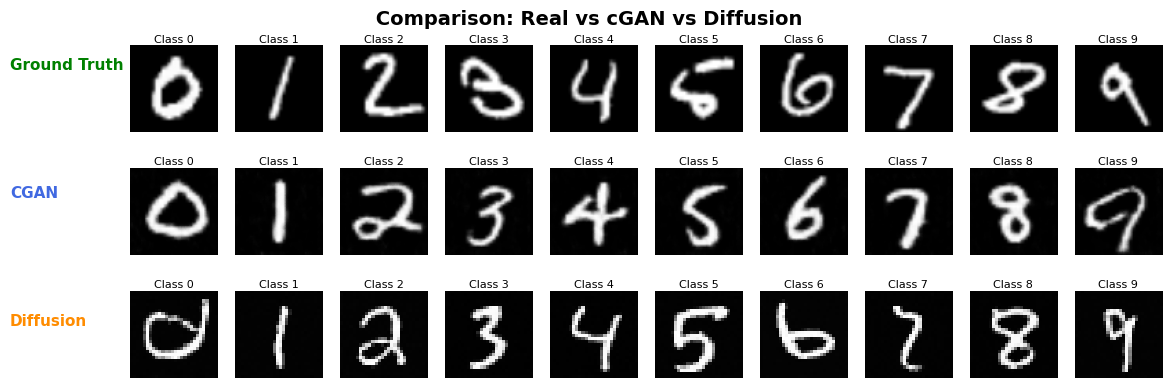

In [11]:
# ToDo: Plot evaluation image using `plot_real_cgan_diffusion`
plot_real_cgan_diffusion(real_imgs, imgs_cgan, imgs_diff, n_classes=10)

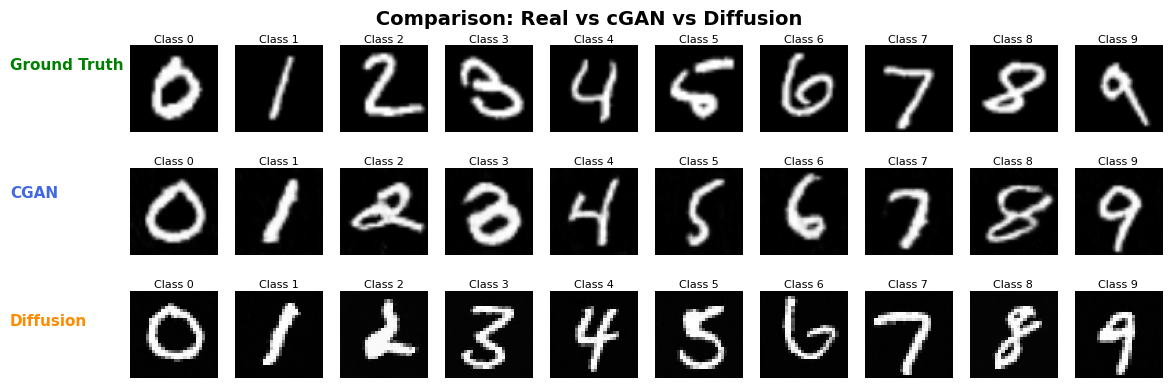

In [17]:
# ToDo: Plot evaluation image using `plot_real_cgan_diffusion`
plot_real_cgan_diffusion(real_imgs, imgs_cgan, imgs_diff, n_classes=10)

In [12]:

fid = FrechetInceptionDistance(normalize=True).to(device)
fid.reset()

In [13]:
torch.cuda.empty_cache()

In [14]:
len(imgs_cgan)

10

In [15]:
# ToDo: Choose a subset of images to run the evaluation on - yeild (real_subset, cgan_subset, diff_subset)

real_subset = real_imgs[:5]
real_subset_diff = real_imgs_diff[:5]
cgan_subset = imgs_cgan[:5]
diff_subset = imgs_diff[:5]

In [16]:
# ToDo: Compute cGAN FID & Diffusion FID 
cgan_fid = compute_fid(real_subset, cgan_subset, device="cuda", batch_size=128)
diff_fid = compute_fid(real_subset_diff, diff_subset, device="cuda", batch_size=128)
print(f" cGAN FID: {cgan_fid:.2f}")
print(f"Diffusion FID: {diff_fid:.2f}")

FID fake: 100%|██████████| 1/1 [00:00<00:00, 22.12it/s]


 cGAN FID: 208.05
Diffusion FID: 171.69


In [25]:
# ToDO: Give a brief analysis of the FID score
#FID measures how closly statistical distribution of AI generated images match the distribution of reference set of real images utilizing pre-trained inception-v3 neural network
#Although diffusion models are expected to outperform cgan by large margin, suprisingly our CGAN FID is very close to diffison FID
#This can be attributed to better training of CGAN model along with model optimizations like using convolutions instead of linear layer in discrimnator and generator networks

### Utility Evaluation (Classifier)

We’ll train a simple CNN classifier on synthetic data from each model,  
then test it on real MNIST data.

If synthetic data are realistic and diverse, the classifier should generalize well to real digits.

In [26]:
cgan_imgs, cgan_labels = generate_conditioned_samples_cgan(cgan_gen, device=device, n_classes=10)
diff_imgs, diff_labels = generate_conditioned_samples_diffusion(
    diff_model, device=device, n_classes=10, timesteps=1000
)


In [27]:
cgan_imgs.shape, diff_imgs.shape

(torch.Size([10, 1, 64, 64]), torch.Size([10, 1, 28, 28]))

In [28]:
cgan_transforms = transforms.Resize(28)
cgan_imgs = cgan_transforms(cgan_imgs)
cgan_imgs.shape

torch.Size([10, 1, 28, 28])

In [29]:

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, TensorDataset
import torch.nn as nn
import torch

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [30]:
real_data = datasets.MNIST(root="../data", train=False, download=True, transform=transform)

In [31]:
def normalize_synthetic(imgs):
    imgs = imgs.clone()
    imgs = (imgs - imgs.min()) / (imgs.max() - imgs.min())  # [0,1]
    imgs = imgs * 2 - 1  # [-1,1]
    return imgs

cgan_imgs = normalize_synthetic(cgan_imgs)
diff_imgs = normalize_synthetic(diff_imgs)

print("Unique labels in CGAN:", torch.unique(cgan_labels))
print("Unique labels in Diffusion:", torch.unique(diff_labels))

Unique labels in CGAN: tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
Unique labels in Diffusion: tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])


In [32]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, 1, 1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, 1, 1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, 1, 1), nn.ReLU()
        )
        self.fc = nn.Sequential(
            nn.Linear(128 * 7 * 7, 128), nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

def train_classifier(model, loader, epochs=3):
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()
    model.train()

    for epoch in range(epochs):
        total_loss = 0
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            preds = model(imgs)
            loss = criterion(preds, labels)

            opt.zero_grad()
            loss.backward()
            opt.step()
            total_loss += loss.item()

        print(f"Epoch {epoch+1}: loss = {total_loss / len(loader):.4f}")
    return model

In [33]:
cgan_ds = TensorDataset(cgan_imgs, cgan_labels)
diff_ds = TensorDataset(diff_imgs, diff_labels)


cgan_loader = DataLoader(cgan_ds, batch_size=128, shuffle=True)
diff_loader = DataLoader(diff_ds, batch_size=128, shuffle=True)
test_loader = DataLoader(real_data, batch_size=256, shuffle=False)

def test_accuracy(model, loader):
    correct, total = 0, 0
    model.eval()
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            preds = model(imgs)
            correct += (preds.argmax(1) == labels).sum().item()
            total += len(labels)
    return correct / total

In [34]:

cnn_cgan = train_classifier(SimpleCNN().to(device), cgan_loader, epochs=20)
cnn_diff = train_classifier(SimpleCNN().to(device), diff_loader, epochs=20)

cgan_acc = test_accuracy(cnn_cgan, test_loader)
diff_acc = test_accuracy(cnn_diff, test_loader)

print(f"Classifier trained on cGAN data → Test accuracy: {cgan_acc:.3f}")
print(f"Classifier trained on Diffusion data → Test accuracy: {diff_acc:.3f}")

Epoch 1: loss = 2.3041
Epoch 2: loss = 2.2417
Epoch 3: loss = 2.1431
Epoch 4: loss = 1.9943
Epoch 5: loss = 1.7726
Epoch 6: loss = 1.4744
Epoch 7: loss = 1.1123
Epoch 8: loss = 0.7240
Epoch 9: loss = 0.3925
Epoch 10: loss = 0.1684
Epoch 11: loss = 0.0611
Epoch 12: loss = 0.0198
Epoch 13: loss = 0.0061
Epoch 14: loss = 0.0018
Epoch 15: loss = 0.0005
Epoch 16: loss = 0.0002
Epoch 17: loss = 0.0001
Epoch 18: loss = 0.0000
Epoch 19: loss = 0.0000
Epoch 20: loss = 0.0000
Epoch 1: loss = 2.3028
Epoch 2: loss = 2.2347
Epoch 3: loss = 2.1143
Epoch 4: loss = 1.9438
Epoch 5: loss = 1.7118
Epoch 6: loss = 1.4189
Epoch 7: loss = 1.0659
Epoch 8: loss = 0.7110
Epoch 9: loss = 0.4005
Epoch 10: loss = 0.1881
Epoch 11: loss = 0.0787
Epoch 12: loss = 0.0307
Epoch 13: loss = 0.0105
Epoch 14: loss = 0.0040
Epoch 15: loss = 0.0015
Epoch 16: loss = 0.0005
Epoch 17: loss = 0.0002
Epoch 18: loss = 0.0000
Epoch 19: loss = 0.0000
Epoch 20: loss = 0.0000
Classifier trained on cGAN data → Test accuracy: 0.547
Cla

In [41]:
#The above method is incorrect to judge how closely synthetic data resemble real data.
#and more so training it on just 10 synthetic sample is not good idea. this is as per the code provided and there are no 'todo's defined to alter the sample size
#Instead Classifier should be first trained on real data and then tested on synthetic data to determine how many of these pass as real data

In [35]:
cnn_real = train_classifier(SimpleCNN().to(device), test_loader, epochs=20)

cgan_acc = test_accuracy(cnn_real, cgan_loader)
diff_acc = test_accuracy(cnn_real, diff_loader)

print(f"Classifier tested on cGAN data → Test accuracy: {cgan_acc:.3f}")
print(f"Classifier tested on Diffusion data → Test accuracy: {diff_acc:.3f}")

Epoch 1: loss = 0.8954
Epoch 2: loss = 0.2732
Epoch 3: loss = 0.1495
Epoch 4: loss = 0.0873
Epoch 5: loss = 0.0610
Epoch 6: loss = 0.0452
Epoch 7: loss = 0.0344
Epoch 8: loss = 0.0249
Epoch 9: loss = 0.0202
Epoch 10: loss = 0.0207
Epoch 11: loss = 0.0250
Epoch 12: loss = 0.0155
Epoch 13: loss = 0.0108
Epoch 14: loss = 0.0071
Epoch 15: loss = 0.0073
Epoch 16: loss = 0.0108
Epoch 17: loss = 0.0051
Epoch 18: loss = 0.0041
Epoch 19: loss = 0.0021
Epoch 20: loss = 0.0013
Classifier tested on cGAN data → Test accuracy: 1.000
Classifier tested on Diffusion data → Test accuracy: 1.000


In [36]:
#So all our synthetic data generated passed the cnn model trained on real mnist data.